In [1]:
import pandas as pd 
import numpy as np
import openpyxl
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df_new = pd.read_excel("student_habits_performance.xlsx")

In [3]:
df_new['social_media_hours'] = df_new['social_media_hours'] + df_new['netflix_hours']
df_new = df_new.drop(columns=['netflix_hours'])

#### Net Productivity

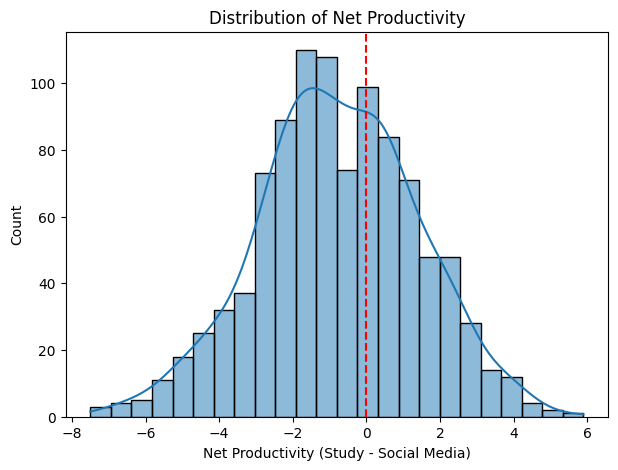

In [6]:
df_new['net_productivity'] = (
    df_new['study_hours_per_day'] - df_new['social_media_hours']
)

plt.figure(figsize=(7,5))
sns.histplot(df_new['net_productivity'], kde=True)

plt.axvline(0, color='red', linestyle='--')

plt.title("Distribution of Net Productivity")
plt.xlabel("Net Productivity (Study - Social Media)")
plt.ylabel("Count")
plt.savefig("eda_plots/net_productivity_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

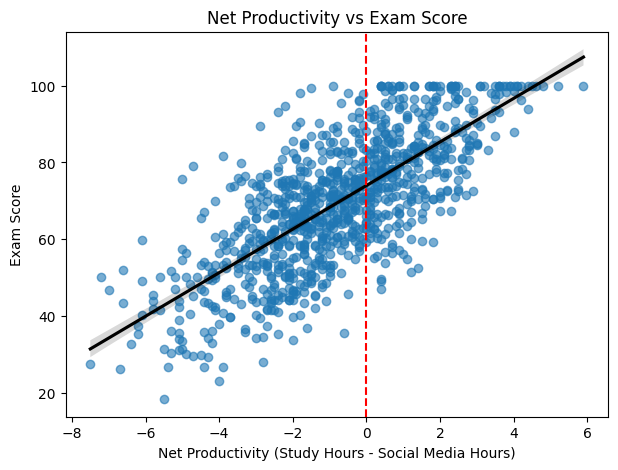

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

df_new['net_productivity'] = (
    df_new['study_hours_per_day'] - df_new['social_media_hours']
)

sns.regplot(
    x='net_productivity',
    y='exam_score',
    data=df_new,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'black'}
)

plt.axvline(0, color='red', linestyle='--')

plt.title("Net Productivity vs Exam Score")
plt.xlabel("Net Productivity (Study Hours - Social Media Hours)")
plt.ylabel("Exam Score")

plt.savefig(
    "cda_plots/net_productivity_vs_exam_score.png",
    dpi=300,
    bbox_inches='tight'
)
plt.savefig("eda_plots/net_productivity_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

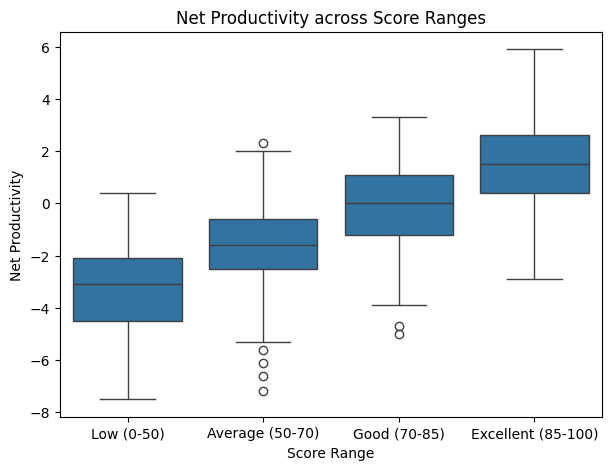

In [8]:
plt.figure(figsize=(7,5))
df_new['score_range'] = pd.cut(
    df_new['exam_score'],
    bins=[0, 50, 70, 85, 100],
    labels=['Low (0-50)', 'Average (50-70)', 'Good (70-85)', 'Excellent (85-100)']
)
sns.boxplot(
    x='score_range',
    y='net_productivity',
    data=df_new
)

plt.title("Net Productivity across Score Ranges")
plt.xlabel("Score Range")
plt.ylabel("Net Productivity")
plt.savefig("eda_plots/net_productivity_accross_scores.png", dpi=300, bbox_inches='tight')
plt.show()

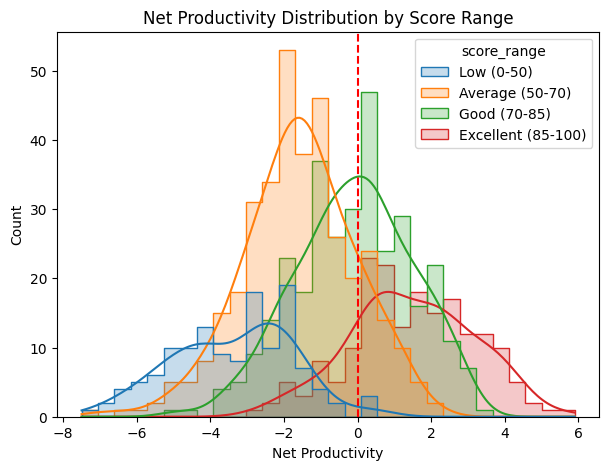

In [9]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df_new,
    x='net_productivity',
    hue='score_range',
    bins=30,
    kde=True,
    element='step'
)

plt.axvline(0, color='red', linestyle='--')

plt.title("Net Productivity Distribution by Score Range")
plt.xlabel("Net Productivity")
plt.ylabel("Count")
plt.savefig("eda_plots/net_productivity_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

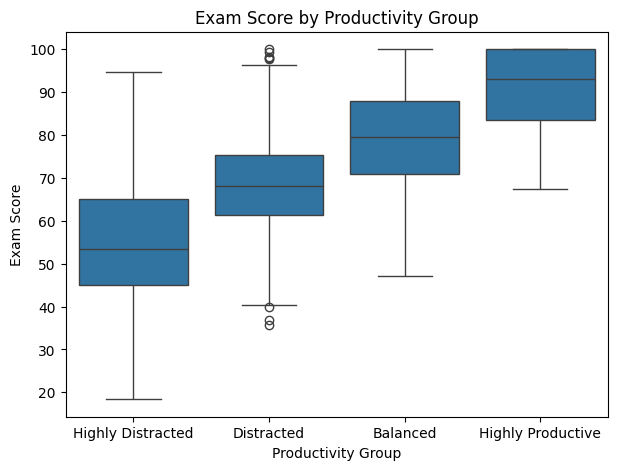

In [12]:
df_new['productivity_group'] = pd.cut(
    df_new['net_productivity'],
    bins=[-10, -2, 0, 2, 10],
    labels=['Highly Distracted', 'Distracted', 'Balanced', 'Highly Productive']
)

plt.figure(figsize=(7,5))
sns.boxplot(x='productivity_group', y='exam_score', data=df_new)

plt.title("Exam Score by Productivity Group")
plt.xlabel("Productivity Group")
plt.ylabel("Exam Score")
plt.savefig("eda_plots/exam_score_by_grp.png", dpi=300, bbox_inches='tight')
plt.show()

In [29]:
df_new.groupby('productivity_group')['exam_score'].mean()

/var/folders/1s/v230lzvj7133nnntptc9gnhc0000gn/T/ipykernel_3261/3635257449.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_new.groupby('productivity_group')['exam_score'].mean()


productivity_group
Highly Distracted    54.734843
Distracted           68.414740
Balanced             79.272727
Highly Productive    90.224272
Name: exam_score, dtype: float64

#### Study hours x Attendance interdependency

In [30]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    "exam_score ~ study_hours_per_day * attendance_percentage",
    data=df_new
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     725.9
Date:                Mon, 04 May 2026   Prob (F-statistic):          4.74e-250
Time:                        20:35:09   Log-Likelihood:                -3665.6
No. Observations:                1000   AIC:                             7339.
Df Residuals:                     996   BIC:                             7359.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

#### Does having a part time job affect final marks?

In [31]:
df_new['productivity_type'] = df_new['net_productivity'].apply(
    lambda x: 'Positive' if x >= 0 else 'Negative'
)
pivot = df_new.pivot_table(
    index='part_time_job',
    columns='productivity_type',
    aggfunc='size',
    fill_value=0
)

print(pivot)

productivity_type  Negative  Positive
part_time_job                        
No                      486       299
Yes                     138        77


In [34]:
#df_new.groupby('part_time_job')['study_hours_per_day'].mean()
job_summary = (
    df_new.groupby('part_time_job')['exam_score']
    .mean()
    .reset_index()
)

job_summary.columns = ['Part-Time Job', 'Average Exam Score']

job_summary['Average Exam Score'] = (
    job_summary['Average Exam Score']
    .round(2)
)

print(job_summary)

  Part-Time Job  Average Exam Score
0            No               69.84
1           Yes               68.74


In [32]:
df_new.groupby('part_time_job')['exam_score'].mean()

part_time_job
No     69.836561
Yes    68.743256
Name: exam_score, dtype: float64

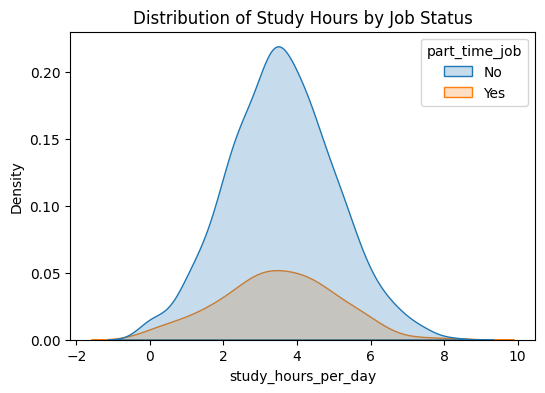

In [15]:
plt.figure(figsize=(6,4))

sns.kdeplot(
    data=df_new,
    x='study_hours_per_day',
    hue='part_time_job',
    fill=True
)

plt.title("Distribution of Study Hours by Job Status")
plt.savefig("eda_plots/study_hours_by_job_status.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
df_new.groupby('part_time_job')['exam_score'].mean()

part_time_job
No     69.836561
Yes    68.743256
Name: exam_score, dtype: float64

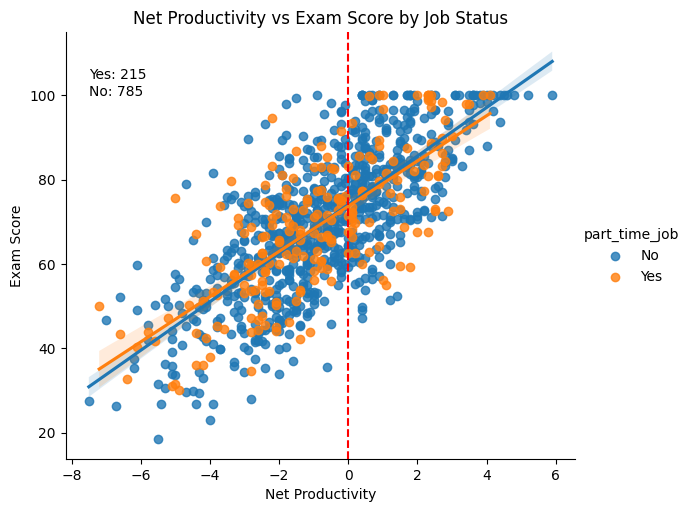

In [31]:
counts = df_new['part_time_job'].value_counts()

g = sns.lmplot(
    x='net_productivity',
    y='exam_score',
    hue='part_time_job',
    data=df_new,
    height=5,
    aspect=1.2
)

plt.text(
    x=df_new['net_productivity'].min(),
    y=df_new['exam_score'].max(),
    s=f"Yes: {counts.get('Yes',0)}\nNo: {counts.get('No',0)}",
    fontsize=10
)

plt.axvline(0, color='red', linestyle='--')

plt.title("Net Productivity vs Exam Score by Job Status")
plt.xlabel("Net Productivity")
plt.ylabel("Exam Score")

plt.savefig(
    "eda_plots/net_productivity_by_job_status.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

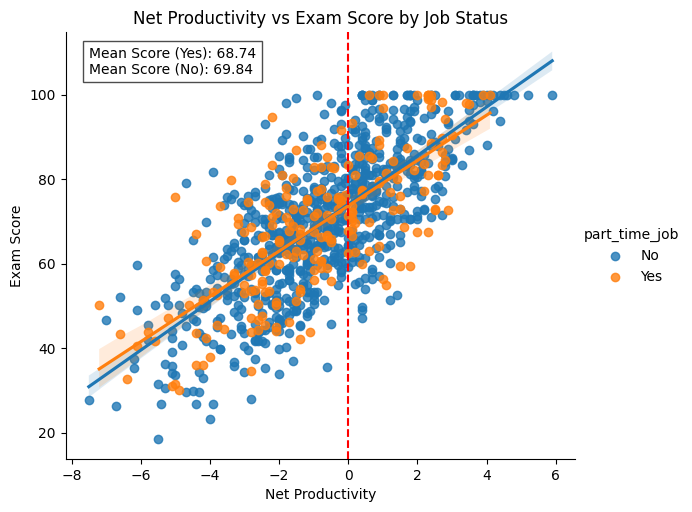

In [37]:
mean_scores = (
    df_new.groupby('part_time_job')['exam_score']
    .mean()
    .round(2)
)
g = sns.lmplot(
    x='net_productivity',
    y='exam_score',
    hue='part_time_job',
    data=df_new,
    height=5,
    aspect=1.2
)

plt.axvline(0, color='red', linestyle='--')

# Add only mean scores
plt.text(
    x=df_new['net_productivity'].min(),
    y=105,
    s=(
        f"Mean Score (Yes): {mean_scores.get('Yes',0)}\n"
        f"Mean Score (No): {mean_scores.get('No',0)}"
    ),
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.title("Net Productivity vs Exam Score by Job Status")
plt.xlabel("Net Productivity")
plt.ylabel("Exam Score")

plt.savefig(
    "eda_plots/net_productivity_by_job_status.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [18]:
df_new.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,net_productivity,score_range,productivity_group
0,S1000,23,Female,0.0,2.3,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,-2.3,Average (50-70),Highly Distracted
1,S1001,20,Female,6.9,5.1,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,1.8,Excellent (85-100),Balanced
2,S1002,21,Male,1.4,4.4,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,-3.0,Low (0-50),Highly Distracted
3,S1003,23,Female,1.0,4.9,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,-3.9,Low (0-50),Highly Distracted
4,S1004,19,Female,5.0,4.9,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,0.1,Average (50-70),Balanced


In [19]:
df_new['sleep_hours'].mean()

np.float64(6.4701)

#### Clustering Students

In [20]:
features = df_new[['net_productivity', 'sleep_hours']]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_new['cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
cluster_summary = df_new.groupby('cluster')[
    ['net_productivity', 'sleep_hours', 'exam_score']
].mean()

print(cluster_summary)

         net_productivity  sleep_hours  exam_score
cluster                                           
0               -2.635548     7.405648   61.068106
1                1.287246     6.886957   82.055362
2               -1.203107     5.268362   64.720056


In [23]:
cluster_summary_sorted = cluster_summary.sort_values('exam_score')
labels = {
    cluster_summary_sorted.index[0]: "Low Productivity - Poor Recovery",
    cluster_summary_sorted.index[1]: "Moderate Balance",
    cluster_summary_sorted.index[2]: "High Productivity - Well Rested"
}

In [24]:
df_new['cluster_label'] = df_new['cluster'].map(labels)

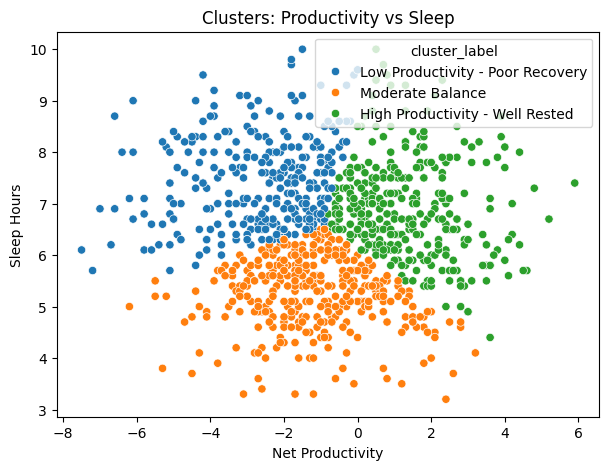

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='net_productivity',
    y='sleep_hours',
    hue='cluster_label',
    data=df_new
)

plt.title("Clusters: Productivity vs Sleep")
plt.xlabel("Net Productivity")
plt.ylabel("Sleep Hours")
plt.savefig("eda_plots/net_productivity_with_sleep_cluster.png", dpi=300, bbox_inches='tight')
plt.show()

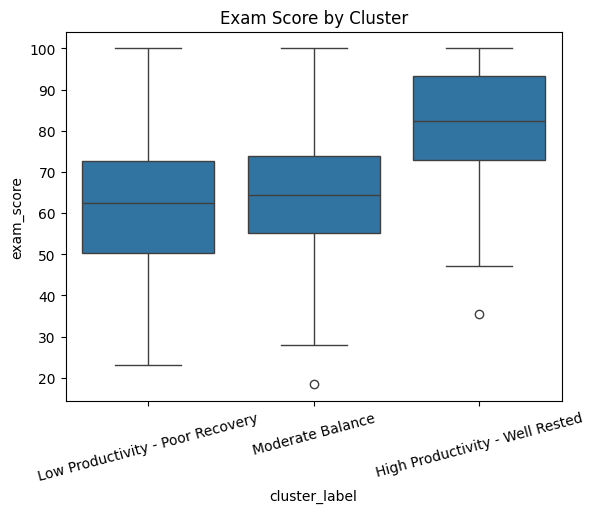

In [53]:
sns.boxplot(
    x='cluster_label',
    y='exam_score',
    data=df_new
)

plt.title("Exam Score by Cluster")
plt.xticks(rotation=15)
plt.show()

In [54]:
df_new.groupby('cluster_label')['exam_score'].mean()

cluster_label
High Productivity - Well Rested     82.055362
Low Productivity - Poor Recovery    61.068106
Moderate Balance                    64.720056
Name: exam_score, dtype: float64